In [2]:
# shapiro test and QQ plot to check normality of data
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import seaborn as sns

In [3]:
data = sns.load_dataset('tips')
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
total_bill_series = data['total_bill']

shapiro_test = stats.shapiro(total_bill_series)
print('Test statistic(w):',shapiro_test.statistic)
print('p-value:',shapiro_test.pvalue)

alpha = 0.05
if shapiro_test.pvalue > alpha:
    print('Data is normally distributed')
else:
    print('Data is not normally distributed')

Test statistic(w): 0.9197187941346584
p-value: 3.3245391868090786e-10
Data is not normally distributed


In [7]:
# Central limt throrem
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Test-wilk p-value: 1.9863474999979633e-11
Data is normally distributed


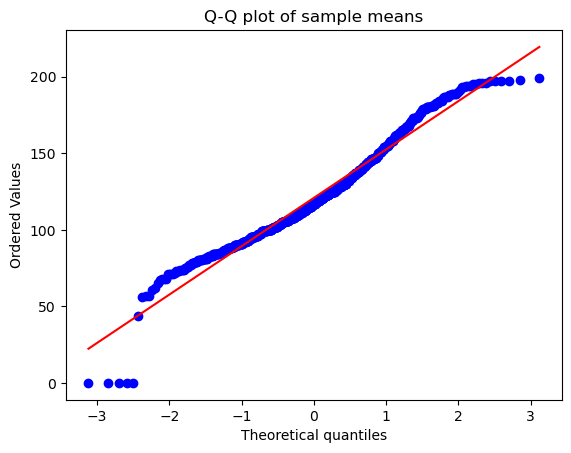

In [8]:
shapiro_test = stats.shapiro(df['Glucose'])
print('Test-wilk p-value:',shapiro_test.pvalue)

alpha = 0.05
if shapiro_test.pvalue > alpha:
    print('Data is not normally distributed')
else:
    print('Data is normally distributed')

stats.probplot(df['Glucose'],dist='norm',plot=plt)
plt.title('Q-Q plot of sample means')
plt.show()

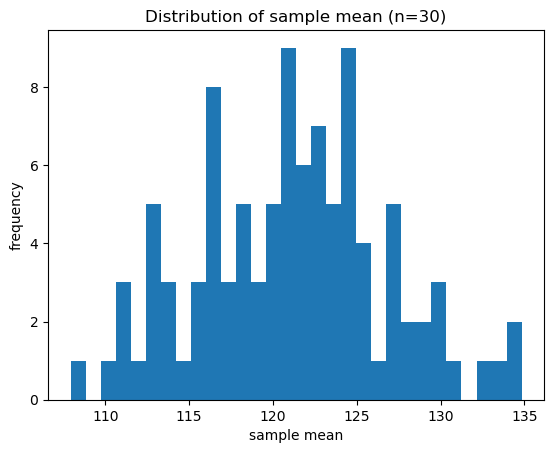

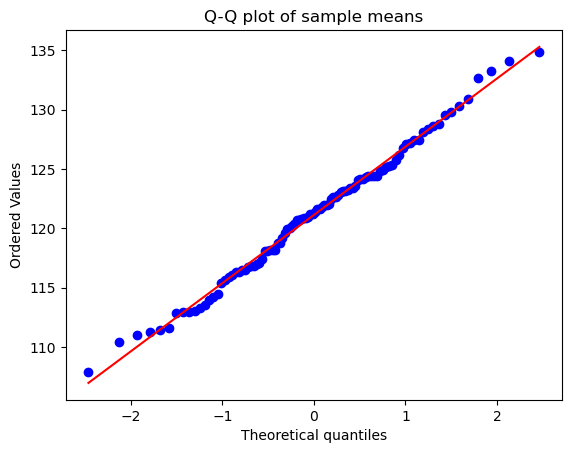

Test-wilk p-value: 0.8163997321058021
Data is normally distributed


In [10]:
# central limit theorem
sample_means =[]
n_samples = 100
sample_size = 30

for _ in range(n_samples):
    sample = df['Glucose'].sample(n=sample_size,replace=True)
    sample_means.append(sample.mean())

# plot 
plt.hist(sample_means,bins=30)
plt.title('Distribution of sample mean (n=30)')
plt.xlabel('sample mean')
plt.ylabel('frequency')
plt.show()

stats.probplot(sample_means,dist='norm',plot=plt)
plt.title('Q-Q plot of sample means')
plt.show()

shapiro_test = stats.shapiro(sample_means)
print('Test-wilk p-value:',shapiro_test.pvalue)

alpha = 0.05
if shapiro_test.pvalue < 0.05:
    print('Data is not normally distributed')
else:
    print('Data is normally distributed')